In [1]:
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd
from scipy.optimize import curve_fit

In [3]:
df1 = pd.read_excel('../data/Exp05_Mach_Zehnder.xlsx',"Sheet1")

In [4]:
print(df1.columns)

Index(['Pressure(mm Hg)', 'No of fringes shifted '], dtype='object')


In [5]:
print(df1['Pressure(mm Hg)'])
print(df1['No of fringes shifted '])


0       6
1      40
2      66
3      88
4     120
5     144
6     170
7     190
8     220
9     248
10    276
Name: Pressure(mm Hg), dtype: int64
0      0
1      1
2      2
3      3
4      4
5      5
6      6
7      7
8      8
9      9
10    10
Name: No of fringes shifted , dtype: int64


In [ ]:
pressure_arr = df1['Pressure(mm Hg)'].to_numpy()
fring_arr = df1['No of fringes shifted '].to_numpy()

In [6]:
def stLine(x, p1, p2):
    return p1 * x + p2

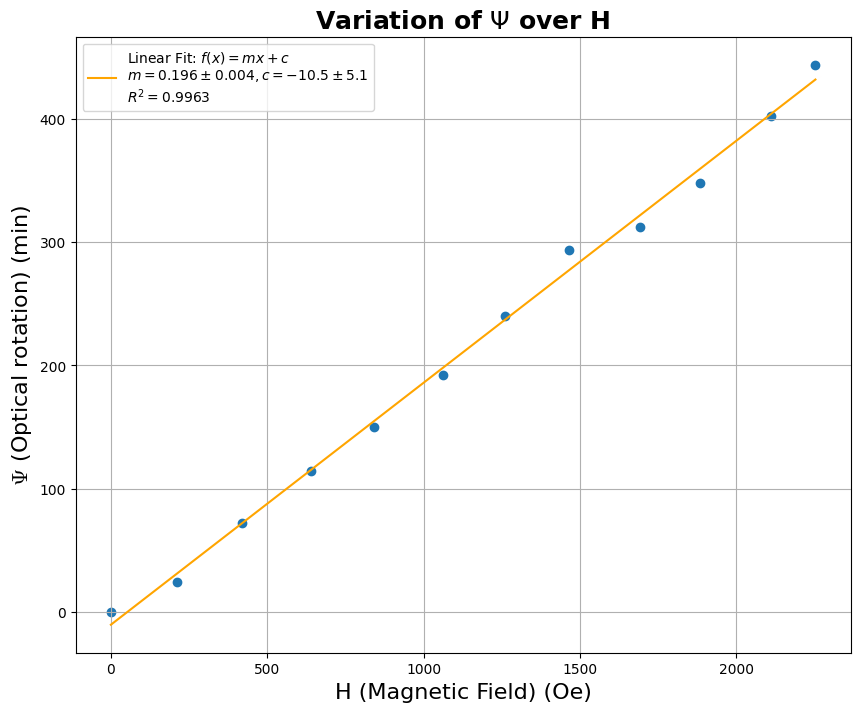

In [8]:
plt.figure(figsize=(10,8))

# Scatter plot
plt.scatter(magnetic_arr, angle_arr)

# Curve fitting
params, pcov = curve_fit(stLine, magnetic_arr, angle_arr)
perr = np.sqrt(np.diag(pcov))

# Predicted values
y_pred = stLine(magnetic_arr, *params)

# R^2 calculation
ss_res = np.sum((angle_arr - y_pred)**2)
ss_tot = np.sum((angle_arr - np.mean(angle_arr))**2)
r_squared = 1 - (ss_res / ss_tot)

# Plot fitted line
plt.plot(
    magnetic_arr,
    stLine(magnetic_arr, *params),
    color='orange',
    label=(
        f"Linear Fit: $f(x)=mx+c$\n"
        f"$m = {params[0]:.3f} \\pm {perr[0]:.3f}, "
        f"c = {params[1]:.1f} \\pm {perr[1]:.1f}$\n"
        f"$R^2 = {r_squared:.4f}$"
    )
)

# Labels and styling
plt.xlabel("H (Magnetic Field) (Oe)", fontsize=16)
plt.ylabel(r"$\Psi$ (Optical rotation) (min)", math_fontfamily='cm', fontsize=16)
plt.title(r"Variation of $\Psi$ over H", fontsize=18, fontweight='bold')

plt.legend(loc="best")
plt.grid(True)

# Save and show
plt.savefig('Plot1.pdf', bbox_inches='tight', dpi=700)
plt.show()

In [9]:
df2 = pd.read_excel('../data/Faraday_data.xlsx',"Sheet2")

In [10]:
print(df2.columns)

Index(['Current ', 'Magnetic field ', 'Intensity (uA)'], dtype='object')


In [11]:
print(df2['Intensity (uA)'])
print(df2['Current '])


0      0.8
1      1.3
2      2.5
3      4.1
4      6.9
5      9.8
6     12.8
7     16.2
8     20.3
9     24.5
10    28.4
Name: Intensity (uA), dtype: float64
0     0.00
1     0.40
2     0.84
3     1.12
4     1.63
5     2.05
6     2.43
7     2.83
8     3.16
9     3.60
10    3.99
Name: Current , dtype: float64


In [12]:
intensity_arr = df2['Intensity (uA)'].to_numpy()
current_arr = df2['Current '].to_numpy()

In [13]:
def sine_sq(x, A, omega, phase, offset):
    return A * (np.sin(omega * x + phase))**2 + offset

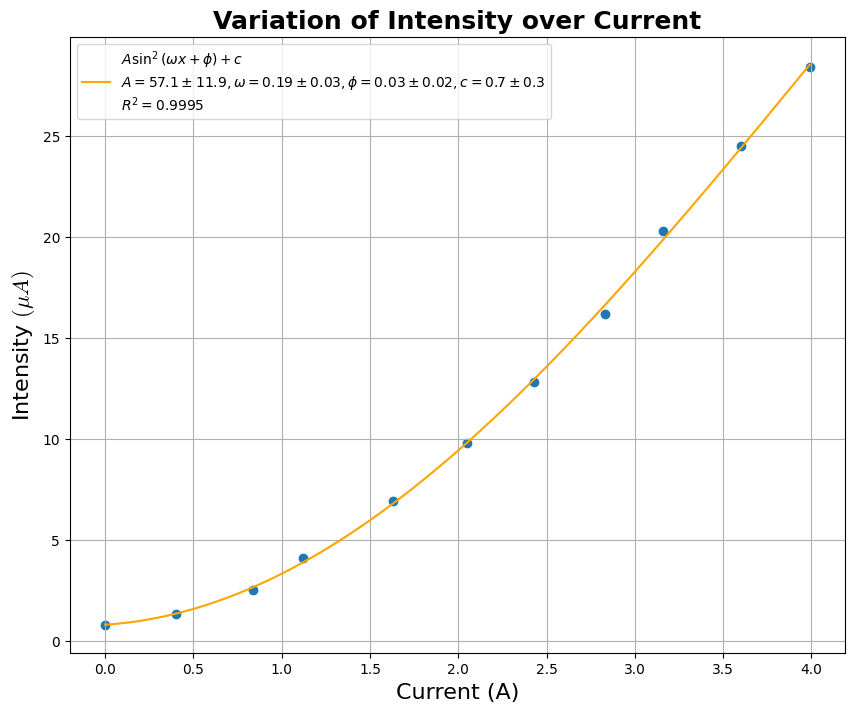

In [14]:
plt.figure(figsize=(10,8))

# Scatter plot
plt.scatter(current_arr, intensity_arr)

# Initial guess
x_range = np.max(current_arr) - np.min(current_arr)
omega_guess = (np.pi / 2) / x_range 
p0 = [np.max(intensity_arr), omega_guess, 0, np.min(intensity_arr)]

# Curve fitting
params, pcov = curve_fit(sine_sq, current_arr, intensity_arr, p0=p0)
perr = np.sqrt(np.diag(pcov))

# Predicted values (for R^2)
y_pred = sine_sq(current_arr, *params)

# R^2 calculation
ss_res = np.sum((intensity_arr - y_pred)**2)
ss_tot = np.sum((intensity_arr - np.mean(intensity_arr))**2)
r_squared = 1 - (ss_res / ss_tot)

# Smooth curve for plotting
x_fit = np.linspace(np.min(current_arr), np.max(current_arr), 500)

# Legend label
legend_label = (
    rf"$A \sin^2(\omega x + \phi) + c$" + "\n"
    rf"$A = {params[0]:.1f} \pm {perr[0]:.1f}, $"
    rf"$\omega = {params[1]:.2f} \pm {perr[1]:.2f}, $"
    rf"$\phi = {params[2]:.2f} \pm {perr[2]:.2f}, $"
    rf"$c = {params[3]:.1f} \pm {perr[3]:.1f}$" + "\n"
    rf"$R^2 = {r_squared:.4f}$"
)

# Plot fitted curve
plt.plot(
    x_fit,
    sine_sq(x_fit, *params),
    color='orange',
    label=legend_label
)

# Labels and styling
plt.xlabel("Current (A)", fontsize=16)
plt.ylabel(r"Intensity $(\mu A)$", math_fontfamily='cm', fontsize=16)
plt.title(r"Variation of Intensity over Current", fontsize=18, fontweight='bold')

plt.legend(loc="best")
plt.grid(True)

# Save and show
plt.savefig('Plot2.pdf', bbox_inches='tight', dpi=700)
plt.show()